# Single-token DNA manifold diagnostics

Short tests for the Stage-1 one-token model: repeat-length control, motif generalisation, latent/string geometry, and interpolation.

In [8]:
from pathlib import Path
import sys, time, math, difflib
import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    from rapidfuzz import fuzz
except Exception:
    fuzz = None

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.dna_single_token_entropy_curriculum_autoencoder import build_model, sequence_to_tensor, tensor_to_sequence

CKPT = ROOT / 'checkpoints/dna_single_token_program_easy_len48/best.pt'
print('checkpoint:', CKPT)
print('exists:', CKPT.exists())

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('device:', device)

t0 = time.perf_counter()
checkpoint = torch.load(CKPT, map_location='cpu')
print(f'loaded checkpoint in {time.perf_counter() - t0:.2f}s')

class Args: pass
args = Args()
for k, v in checkpoint['args'].items():
    setattr(args, k, v)

model = build_model(args).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print('step:', checkpoint.get('step'), 'val_loss:', checkpoint.get('validation_loss'))
print('seq_len:', args.seq_len, 'latent_dim:', args.latent_dim, 'params:', sum(p.numel() for p in model.parameters()))

checkpoint: /Users/ogw/Documents/GitHub/Central_Dogma_AI/checkpoints/dna_single_token_program_easy_len48/best.pt
exists: True
device: mps
loaded checkpoint in 0.01s
step: 5650 val_loss: 0.04275334486737847
seq_len: 48 latent_dim: 32 params: 179782


In [9]:
BASE_COLORS = {'A':'#4caf50', 'C':'#2196f3', 'G':'#ff9800', 'T':'#e91e63'}

def ratio(a, b):
    if fuzz is not None:
        return fuzz.ratio(a, b) / 100.0
    return difflib.SequenceMatcher(None, a, b).ratio()

def batch_tensors(seqs):
    target = torch.zeros(len(seqs), args.seq_len, dtype=torch.long)
    mask = torch.zeros(len(seqs), args.seq_len, dtype=torch.float32)
    for i, seq in enumerate(seqs):
        seq = seq[:args.seq_len]
        target[i, :len(seq)] = sequence_to_tensor(seq)
        mask[i, :len(seq)] = 1
    return target.to(device), mask.to(device)

@torch.no_grad()
def encode_decode(seqs):
    target, mask = batch_tensors(seqs)
    out = model(target, mask)
    pred = out['soft_dna'].argmax(-1).detach().cpu()
    lengths = out['total_len'].detach().cpu().round().clamp(1, args.seq_len).long().tolist()
    decoded = [tensor_to_sequence(pred[i, :lengths[i]]) for i in range(len(seqs))]
    lat = out['latents'][:, 0, :].detach().cpu()
    usage = out['token_usage'][:, 0].detach().cpu()
    return {'decoded': decoded, 'latent': lat, 'usage': usage, 'lengths': lengths, 'raw': out}

@torch.no_grad()
def decode_latent(latent, usage=1.0):
    lat = torch.as_tensor(latent, dtype=torch.float32, device=device)[None, None, :]
    use = torch.tensor([[usage]], dtype=torch.float32, device=device)
    out = model.decode(lat, use, args.seq_len)
    pred = out['soft_dna'].argmax(-1)[0].detach().cpu()
    length = int(out['total_len'][0].detach().cpu().round().clamp(1, args.seq_len).item())
    return tensor_to_sequence(pred[:length]), length

def colour_seq(seq):
    from IPython.display import HTML
    spans = ''.join(f'<span style="background:{BASE_COLORS[b]};color:white;padding:1px 3px;margin:1px;font-family:monospace">{b}</span>' for b in seq)
    return HTML(f'<div style="line-height:1.8">{spans}</div>')

## 1. Repeat-length sweep

Does one latent/token scale motif repeat count into emitted length?

target: A | decoded: AC | sim: 0.667
target: GT | decoded: GT | sim: 1.0
target: CGACGACGACGACGACGACGACGACGACGACGACGACGACGACGACGA | decoded: CGACGACGACGACGACGACGACGACGACGACGACGACGGCCGG | sim: 0.901


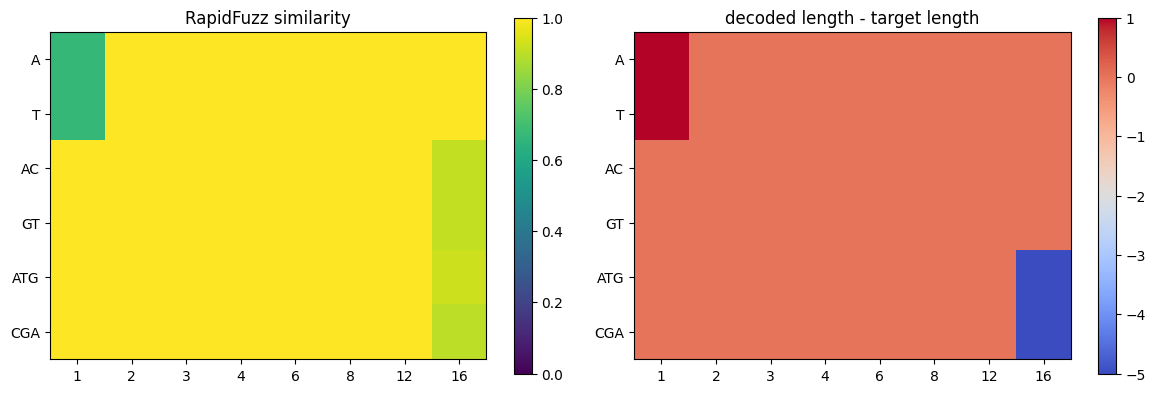

In [10]:
motifs = ['A', 'T', 'AC', 'GT', 'ATG', 'CGA']
repeats = [1, 2, 3, 4, 6, 8, 12, 16]
seqs = [(m * r)[:args.seq_len] for m in motifs for r in repeats]
labels = [(m, r, len((m * r)[:args.seq_len])) for m in motifs for r in repeats]
res = encode_decode(seqs)

sim = np.array([ratio(a, b) for a, b in zip(seqs, res['decoded'])]).reshape(len(motifs), len(repeats))
out_len = np.array(res['lengths']).reshape(len(motifs), len(repeats))
target_len = np.array([x[2] for x in labels]).reshape(len(motifs), len(repeats))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(sim, vmin=0, vmax=1, cmap='viridis')
axes[0].set_title('RapidFuzz similarity')
axes[0].set_xticks(range(len(repeats)), repeats)
axes[0].set_yticks(range(len(motifs)), motifs)
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(out_len - target_len, cmap='coolwarm')
axes[1].set_title('decoded length - target length')
axes[1].set_xticks(range(len(repeats)), repeats)
axes[1].set_yticks(range(len(motifs)), motifs)
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()

for idx in [0, len(seqs)//2, len(seqs)-1]:
    print('target:', seqs[idx], '| decoded:', res['decoded'][idx], '| sim:', round(ratio(seqs[idx], res['decoded'][idx]), 3))

## 2. Latent geometry

Do string-similar sequences become latent-similar sequences?

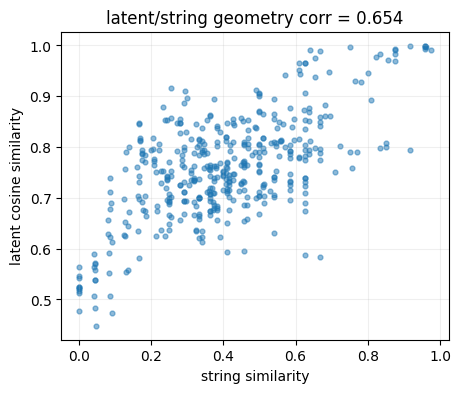

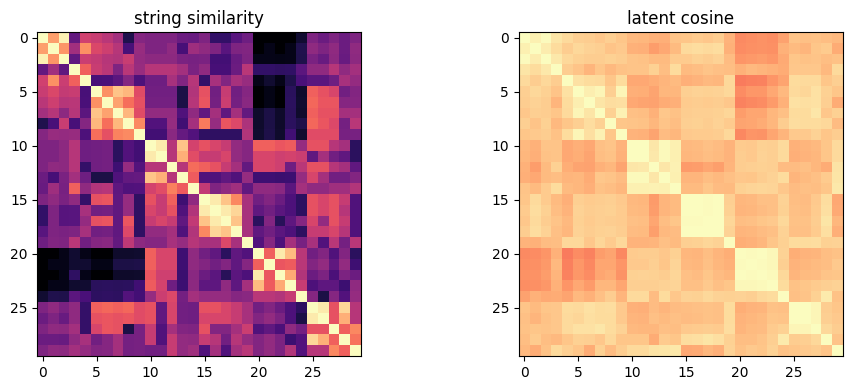

In [11]:
rng = np.random.default_rng(3)
base_seqs = ['A' * 20, 'AC' * 12, 'ATG' * 8, 'CGA' * 8, 'GT' * 12, 'TAC' * 8]

def mutate(seq, n=2):
    bases = np.array(list(seq))
    for _ in range(n):
        if rng.random() < 0.7 and len(bases) > 0:
            i = rng.integers(0, len(bases))
            choices = [b for b in 'ACGT' if b != bases[i]]
            bases[i] = rng.choice(choices)
        elif rng.random() < 0.5 and len(bases) > 1:
            bases = np.delete(bases, rng.integers(0, len(bases)))
        elif len(bases) < args.seq_len:
            bases = np.insert(bases, rng.integers(0, len(bases)+1), rng.choice(list('ACGT')))
    return ''.join(bases.tolist())[:args.seq_len]

seqs = []
for s in base_seqs:
    seqs.append(s[:args.seq_len])
    for edits in [1, 2, 4, 6]:
        seqs.append(mutate(s[:args.seq_len], edits))

res = encode_decode(seqs)
z = torch.nn.functional.normalize(res['latent'], dim=-1).numpy()
latent_sim = z @ z.T
string_sim = np.array([[ratio(a, b) for b in seqs] for a in seqs])
tri = np.triu_indices(len(seqs), k=1)
corr = np.corrcoef(string_sim[tri], latent_sim[tri])[0, 1]

plt.figure(figsize=(5, 4))
plt.scatter(string_sim[tri], latent_sim[tri], s=12, alpha=0.5)
plt.xlabel('string similarity')
plt.ylabel('latent cosine similarity')
plt.title(f'latent/string geometry corr = {corr:.3f}')
plt.grid(alpha=0.2)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(string_sim, vmin=0, vmax=1, cmap='magma'); axes[0].set_title('string similarity')
axes[1].imshow(latent_sim, vmin=-1, vmax=1, cmap='magma'); axes[1].set_title('latent cosine')
plt.tight_layout()

## 2b. Structured repeat-unit geometry

Homopolymers, di-, tri-, and 4-mer motifs across repeat counts. This is a cleaner test of whether repeat count and motif identity organise smoothly in latent space.

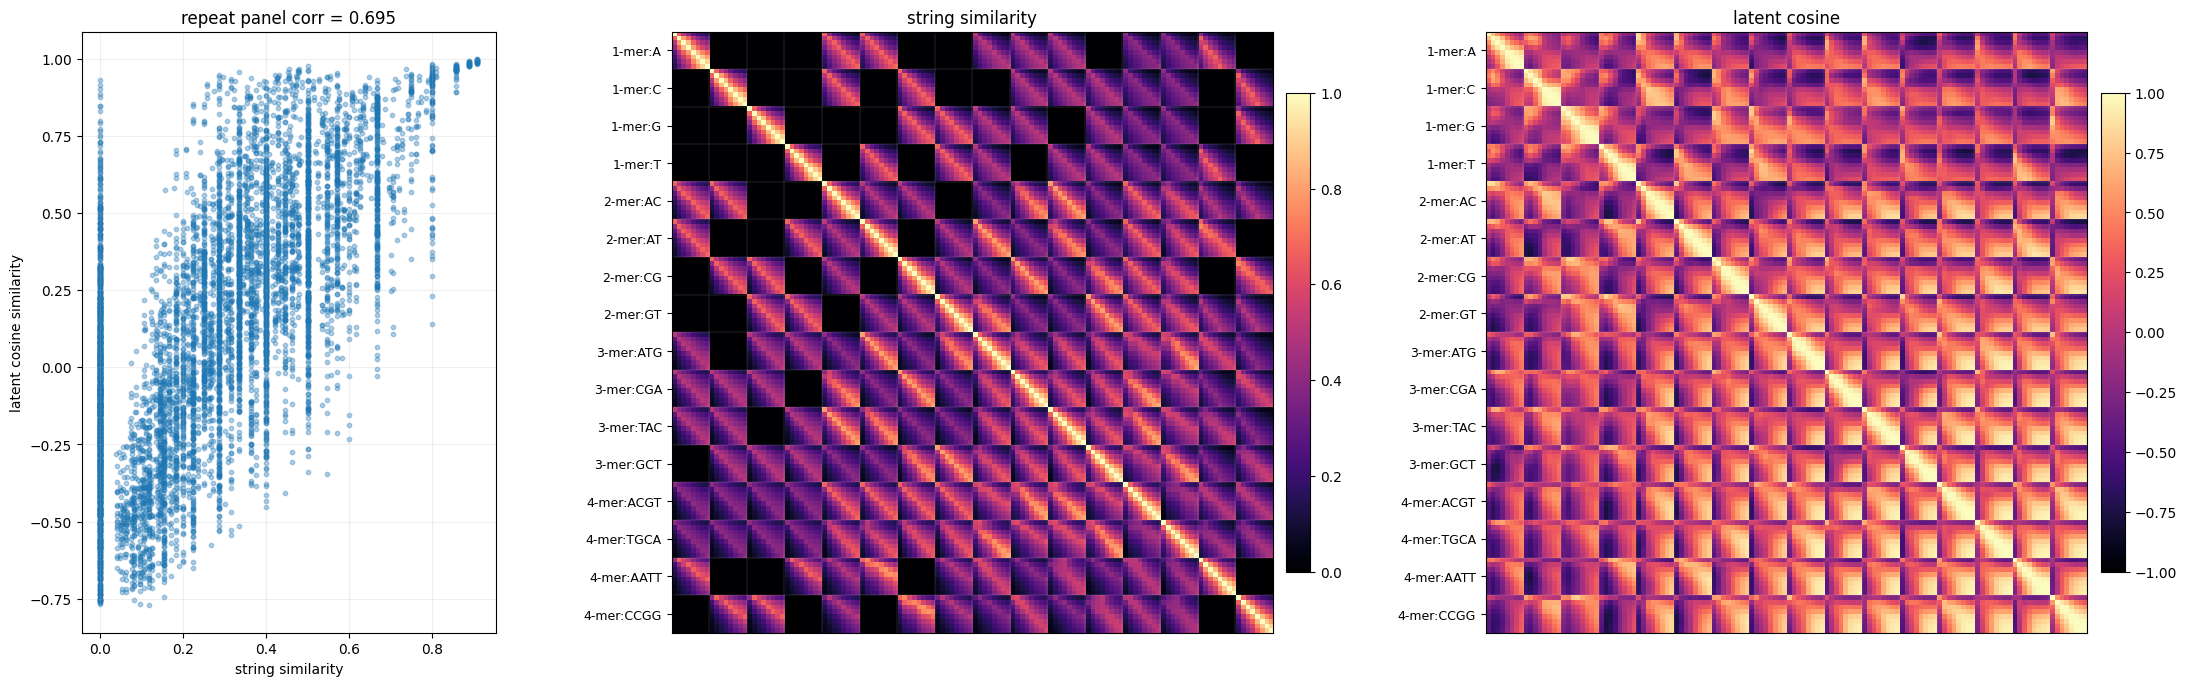

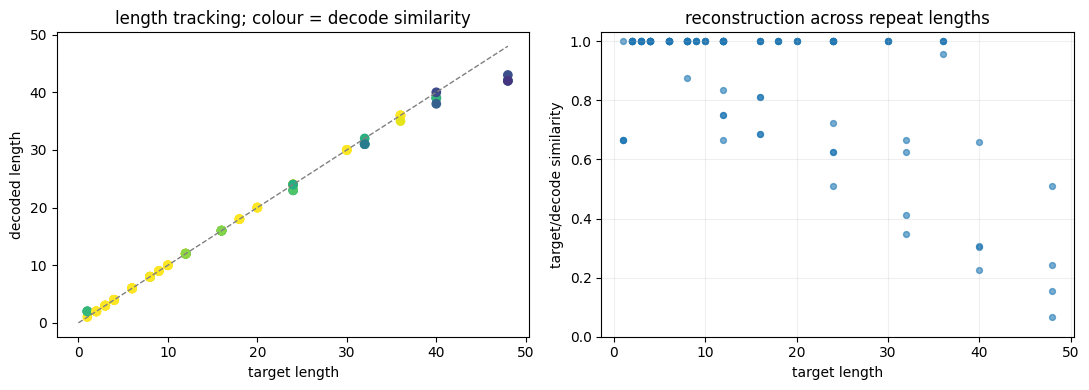

('1-mer', 'A', 1, 1) target: A | decoded: AC | sim: 0.667
('1-mer', 'A', 12, 12) target: AAAAAAAAAAAA | decoded: AAAAAAAAAAAA | sim: 1.0
('3-mer', 'ATG', 1, 3) target: ATG | decoded: ATG | sim: 1.0
('4-mer', 'CCGG', 12, 48) target: CCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGG | decoded: CCGGGCGGGGGCGGGGGCGGGGGCGGGGGCGGCGGCGGGCCG | sim: 0.156


In [12]:
repeat_motifs = {
    '1-mer': ['A', 'C', 'G', 'T'],
    '2-mer': ['AC', 'AT', 'CG', 'GT'],
    '3-mer': ['ATG', 'CGA', 'TAC', 'GCT'],
    '4-mer': ['ACGT', 'TGCA', 'AATT', 'CCGG'],
}
repeat_counts = [1, 2, 3, 4, 6, 8, 10, 12]

seqs, labels, y_ticks = [], [], []
for group, motifs in repeat_motifs.items():
    for motif in motifs:
        y_ticks.append(f'{group}:{motif}')
        for count in repeat_counts:
            seq = (motif * count)[:args.seq_len]
            seqs.append(seq)
            labels.append((group, motif, count, len(seq)))

res = encode_decode(seqs)
z = torch.nn.functional.normalize(res['latent'], dim=-1).numpy()
latent_sim = z @ z.T
string_sim = np.array([[ratio(a, b) for b in seqs] for a in seqs])
tri = np.triu_indices(len(seqs), k=1)
corr = np.corrcoef(string_sim[tri], latent_sim[tri])[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(22, 7), gridspec_kw={'width_ratios': [1.0, 1.65, 1.65]})
axes[0].scatter(string_sim[tri], latent_sim[tri], s=10, alpha=0.35)
axes[0].set_xlabel('string similarity')
axes[0].set_ylabel('latent cosine similarity')
axes[0].set_title(f'repeat panel corr = {corr:.3f}')
axes[0].grid(alpha=0.2)

im1 = axes[1].imshow(string_sim, vmin=0, vmax=1, cmap='magma')
axes[1].set_title('string similarity')
fig.colorbar(im1, ax=axes[1], fraction=0.035, pad=0.02)

im2 = axes[2].imshow(latent_sim, vmin=-1, vmax=1, cmap='magma')
axes[2].set_title('latent cosine')
fig.colorbar(im2, ax=axes[2], fraction=0.035, pad=0.02)

block = len(repeat_counts)
for ax in axes[1:]:
    for boundary in range(block, len(seqs), block):
        ax.axhline(boundary - 0.5, color='white', lw=0.25, alpha=0.4)
        ax.axvline(boundary - 0.5, color='white', lw=0.25, alpha=0.4)
    ax.set_xticks([])
    ax.set_yticks([i * block + block/2 - 0.5 for i in range(len(y_ticks))], y_ticks, fontsize=9)
    ax.set_aspect('equal')
plt.tight_layout(pad=1.2)
plt.show()

# Per motif: does decoded length track repeat-derived target length?
target_lengths = np.array([x[3] for x in labels])
decoded_lengths = np.array(res['lengths'])
seq_ratio = np.array([ratio(a, b) for a, b in zip(seqs, res['decoded'])])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(target_lengths, decoded_lengths, c=seq_ratio, cmap='viridis', vmin=0, vmax=1)
axes[0].plot([0, args.seq_len], [0, args.seq_len], '--', color='gray', lw=1)
axes[0].set_xlabel('target length')
axes[0].set_ylabel('decoded length')
axes[0].set_title('length tracking; colour = decode similarity')

axes[1].scatter(target_lengths, seq_ratio, s=18, alpha=0.6)
axes[1].set_xlabel('target length')
axes[1].set_ylabel('target/decode similarity')
axes[1].set_ylim(0, 1.03)
axes[1].set_title('reconstruction across repeat lengths')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

for idx in [0, block-1, len(seqs)//2, len(seqs)-1]:
    print(labels[idx], 'target:', seqs[idx], '| decoded:', res['decoded'][idx], '| sim:', round(seq_ratio[idx], 3))


## 3. Latent interpolation

Interpolate between two encoded sequences and decode each point.

In [13]:
start = 'AC' * 10
end = 'GTG' * 8
enc = encode_decode([start, end])
z0, z1 = enc['latent'][0], enc['latent'][1]
u0, u1 = float(enc['usage'][0]), float(enc['usage'][1])

print('start target :', start)
print('start decode :', enc['decoded'][0])
print('end target   :', end)
print('end decode   :', enc['decoded'][1])
print()

for alpha in np.linspace(0, 1, 9):
    z = (1-alpha) * z0 + alpha * z1
    usage = (1-alpha) * u0 + alpha * u1
    decoded, length = decode_latent(z, usage=usage)
    print(f'a={alpha:.2f} len={length:02d} sim_start={ratio(start, decoded):.2f} sim_end={ratio(end, decoded):.2f}  {decoded}')

start target : ACACACACACACACACACAC
start decode : ACACACACACACACACACAC
end target   : GTGGTGGTGGTGGTGGTGGTGGTG
end decode   : GTGGTGGTGGTGGTGGTGGTGGTG

a=0.00 len=20 sim_start=1.00 sim_end=0.00  ACACACACACACACACACAC
a=0.12 len=21 sim_start=0.98 sim_end=0.00  ACACACACACACACACACACA
a=0.25 len=21 sim_start=0.98 sim_end=0.00  ACACACACACACACACACACA
a=0.38 len=22 sim_start=0.81 sim_end=0.13  CCTGACACACACACACACACAG
a=0.50 len=22 sim_start=0.24 sim_end=0.30  CCTGTGACGGAGACAGAGACGG
a=0.62 len=23 sim_start=0.33 sim_end=0.68  CCGGTGGCGGTGGCGGCGGCGGC
a=0.75 len=23 sim_start=0.14 sim_end=0.85  CCGGTGGTGGTGGTGGTGGTGGC
a=0.88 len=23 sim_start=0.00 sim_end=0.98  GTGGTGGTGGTGGTGGTGGTGGT
a=1.00 len=24 sim_start=0.00 sim_end=1.00  GTGGTGGTGGTGGTGGTGGTGGTG


## 3b. Repeat-count interpolation

Encode the same motif at a low and high repeat count, interpolate between the two latents, then check whether decoded length/repeat count changes smoothly.

In [ ]:
def repeat_count_interpolation(motif='AC', low=2, high=12, steps=13):
    start = (motif * low)[:args.seq_len]
    end = (motif * high)[:args.seq_len]
    enc = encode_decode([start, end])
    z0, z1 = enc['latent'][0], enc['latent'][1]
    u0, u1 = float(enc['usage'][0]), float(enc['usage'][1])
    rows = []
    for alpha in np.linspace(0, 1, steps):
        z = (1-alpha) * z0 + alpha * z1
        usage = (1-alpha) * u0 + alpha * u1
        decoded, dec_len = decode_latent(z, usage=usage)
        ideal_len = (1-alpha) * len(start) + alpha * len(end)
        rows.append({
            'alpha': alpha,
            'decoded': decoded,
            'decoded_len': dec_len,
            'approx_repeats': dec_len / max(1, len(motif)),
            'ideal_len': ideal_len,
            'sim_low': ratio(start, decoded),
            'sim_high': ratio(end, decoded),
            'sim_motif_string': ratio((motif * max(1, round(dec_len / len(motif))))[:args.seq_len], decoded),
        })
    return start, end, rows

motif_tests = [('A', 2, 24), ('AC', 2, 16), ('ATG', 2, 12), ('ACGT', 2, 10)]
fig, axes = plt.subplots(len(motif_tests), 2, figsize=(12, 3.0 * len(motif_tests)), sharex=True)
if len(motif_tests) == 1:
    axes = np.array([axes])

all_rows = {}
for row_idx, (motif, low, high) in enumerate(motif_tests):
    start, end, rows = repeat_count_interpolation(motif, low, high, steps=13)
    all_rows[motif] = rows
    alphas = np.array([r['alpha'] for r in rows])
    dec_lens = np.array([r['decoded_len'] for r in rows])
    ideal = np.array([r['ideal_len'] for r in rows])
    sim_low = np.array([r['sim_low'] for r in rows])
    sim_high = np.array([r['sim_high'] for r in rows])
    sim_motif = np.array([r['sim_motif_string'] for r in rows])

    ax = axes[row_idx, 0]
    ax.plot(alphas, ideal, '--', color='gray', label='linear target length')
    ax.plot(alphas, dec_lens, marker='o', label='decoded length')
    ax.set_ylabel(f'{motif} length')
    ax.set_title(f'{motif}: {low}x → {high}x')
    ax.grid(alpha=0.2)
    ax.legend(loc='best', fontsize=8)

    ax = axes[row_idx, 1]
    ax.plot(alphas, sim_low, marker='o', label='sim to low')
    ax.plot(alphas, sim_high, marker='o', label='sim to high')
    ax.plot(alphas, sim_motif, marker='o', label='sim to nearest motif repeat')
    ax.set_ylim(0, 1.03)
    ax.set_title('decoded string similarity')
    ax.grid(alpha=0.2)
    ax.legend(loc='best', fontsize=8)

axes[-1, 0].set_xlabel('latent interpolation alpha')
axes[-1, 1].set_xlabel('latent interpolation alpha')
plt.tight_layout()
plt.show()

for motif, rows in all_rows.items():
    print(f'\n{motif} interpolation')
    for r in rows[::3]:
        print(f"a={r['alpha']:.2f} len={r['decoded_len']:02d} reps~{r['approx_repeats']:.1f} motif_sim={r['sim_motif_string']:.2f}  {r['decoded']}")


## 3c. Motif-identity interpolation: A repeat → AC repeat

Interpolate between a homopolymer repeat and a dinucleotide repeat. This asks whether motif identity changes smoothly, collapses abruptly, or passes through odd intermediate repeats.

In [ ]:
def motif_identity_interpolation(start_seq='A' * 24, end_seq='AC' * 12, steps=17):
    enc = encode_decode([start_seq, end_seq])
    z0, z1 = enc['latent'][0], enc['latent'][1]
    u0, u1 = float(enc['usage'][0]), float(enc['usage'][1])
    rows = []
    for alpha in np.linspace(0, 1, steps):
        z = (1-alpha) * z0 + alpha * z1
        usage = (1-alpha) * u0 + alpha * u1
        decoded, dec_len = decode_latent(z, usage=usage)
        rows.append({
            'alpha': alpha,
            'decoded': decoded,
            'decoded_len': dec_len,
            'sim_A': ratio(start_seq, decoded),
            'sim_AC': ratio(end_seq, decoded),
            'A_fraction': decoded.count('A') / max(1, len(decoded)),
            'C_fraction': decoded.count('C') / max(1, len(decoded)),
            'AC_phase_score': ratio(('AC' * ((dec_len + 1)//2))[:dec_len], decoded),
        })
    return rows

rows = motif_identity_interpolation('A' * 24, 'AC' * 12, steps=17)
alphas = np.array([r['alpha'] for r in rows])
lengths = np.array([r['decoded_len'] for r in rows])
sim_A = np.array([r['sim_A'] for r in rows])
sim_AC = np.array([r['sim_AC'] for r in rows])
a_frac = np.array([r['A_fraction'] for r in rows])
c_frac = np.array([r['C_fraction'] for r in rows])
phase = np.array([r['AC_phase_score'] for r in rows])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(alphas, lengths, marker='o')
axes[0].set_title('decoded length')
axes[0].set_xlabel('alpha: A → AC')
axes[0].set_ylabel('bp')
axes[0].grid(alpha=0.2)

axes[1].plot(alphas, sim_A, marker='o', label='sim to A repeat')
axes[1].plot(alphas, sim_AC, marker='o', label='sim to AC repeat')
axes[1].plot(alphas, phase, marker='o', label='AC phase score')
axes[1].set_ylim(0, 1.03)
axes[1].set_title('endpoint / motif similarity')
axes[1].set_xlabel('alpha')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

axes[2].plot(alphas, a_frac, marker='o', label='A fraction')
axes[2].plot(alphas, c_frac, marker='o', label='C fraction')
axes[2].set_ylim(0, 1.03)
axes[2].set_title('base composition')
axes[2].set_xlabel('alpha')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2)
plt.tight_layout()
plt.show()

for r in rows[::2]:
    print(f"a={r['alpha']:.2f} len={r['decoded_len']:02d} simA={r['sim_A']:.2f} simAC={r['sim_AC']:.2f} ACphase={r['AC_phase_score']:.2f}  {r['decoded']}")


## 4. Single manual sequence

Change `SEQ` and rerun.

In [14]:
SEQ = 'ACACACACACACACACACAC'
res = encode_decode([SEQ])
print('target :', SEQ)
print('decode :', res['decoded'][0])
print('ratio  :', ratio(SEQ, res['decoded'][0]))
print('usage  :', float(res['usage'][0]), 'decoded_len:', res['lengths'][0])
colour_seq(res['decoded'][0])

target : ACACACACACACACACACAC
decode : ACACACACACACACACACAC
ratio  : 1.0
usage  : 0.9640296101570129 decoded_len: 20
